
### Cell 1: 模块目标与输出说明

本 Notebook 只覆盖项目中的两个模块：

1. 数据预处理：识别缺失值与异常值、标准化时间字段、生成派生时间特征，并构建 `10%`、`50%`、`100%` 三个规模化子集。
2. 性能评估基准：对比 Pandas 与 Polars 在数据加载、预处理流水线、代表性聚合任务上的执行时间与峰值内存。

设计原则如下：

- 所有字段均以 `train.parquet` 的真实 schema 为准，不额外假设不存在的列。
- 当前数据集中 `brand`、`cat_0`、`cat_1`、`cat_2`、`cat_3` 的缺失主要使用字符串 `"NA"` 表示，`price` 为字符串列，需要显式转换为数值型。
- 为保证两种框架处理的是同一份输入，先物化统一的原始子集，再分别执行 Pandas 与 Polars 的 benchmark。
- `100%` 全量数据上的 Pandas benchmark 可能占用较高内存，因此加入了基于可用内存的保护开关；当机器内存充足时会自动执行。


In [1]:

from pathlib import Path
import gc
import os
import time
import threading
import warnings

import pandas as pd
import polars as pl

#监控内存占用用的
import psutil
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pl.Config.set_tbl_cols(50)
pl.Config.set_tbl_rows(20)

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "train.parquet"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
RAW_SUBSET_DIR = ARTIFACT_DIR / "raw_subsets"
CLEAN_SUBSET_DIR = ARTIFACT_DIR / "clean_subsets"

for folder in [ARTIFACT_DIR, RAW_SUBSET_DIR, CLEAN_SUBSET_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"当前工作目录: {PROJECT_DIR}")
print(f"数据文件存在: {DATA_PATH.exists()} -> {DATA_PATH}")
print(f"pandas 版本: {pd.__version__}")
print(f"polars 版本: {pl.__version__}")
print(f"psutil 版本: {psutil.__version__}")


当前工作目录: /Users/fangflak/Desktop/CI_proj
数据文件存在: True -> /Users/fangflak/Desktop/CI_proj/train.parquet
pandas 版本: 2.3.3
polars 版本: 1.37.1
psutil 版本: 7.0.0



### Cell 2: 定义通用工具函数

这一部分统一封装三类能力：

- Parquet 读取函数
- 时间与内存 benchmark 函数
- 统一命名与结果整理函数


In [2]:

def get_process_memory_mb() -> float:
    return psutil.Process(os.getpid()).memory_info().rss / 1024 ** 2


def read_parquet_pandas(parquet_path: Path) -> pd.DataFrame:
    return pd.read_parquet(parquet_path, engine="pyarrow", dtype_backend="pyarrow")


def read_parquet_polars(parquet_path: Path) -> pl.DataFrame:
    return pl.read_parquet(parquet_path)


def normalize_label(label: str) -> str:
    return label.replace("%", "pct").replace(" ", "_")


def sample_current_process_memory(stop_event: threading.Event, samples: list[float], interval_seconds: float = 0.05) -> None:
    process = psutil.Process(os.getpid())
    while not stop_event.is_set():
        samples.append(process.memory_info().rss / 1024 ** 2)
        time.sleep(interval_seconds)
    samples.append(process.memory_info().rss / 1024 ** 2)



def benchmark_callable(framework_name: str, operation_name: str, func, repeat: int = 1):
    run_records = []
    last_result = None

    for run_id in range(1, repeat + 1):
        gc.collect()
        baseline_memory_mb = get_process_memory_mb()
        memory_samples = [baseline_memory_mb]
        stop_event = threading.Event()
        monitor_thread = threading.Thread(
            target=sample_current_process_memory,
            args=(stop_event, memory_samples),
            daemon=True,
        )

        start_time = time.perf_counter()
        monitor_thread.start()
        try:
            last_result = func()
        finally:
            stop_event.set()
            monitor_thread.join()

        peak_memory_mb = max(memory_samples)
        elapsed_seconds = time.perf_counter() - start_time

        run_records.append(
            {
                "framework": framework_name,
                "operation": operation_name,
                "run_id": run_id,
                "elapsed_seconds": round(elapsed_seconds, 4),
                "baseline_memory_mb": round(baseline_memory_mb, 2),
                "peak_memory_mb": round(float(peak_memory_mb), 2),
                "delta_memory_mb": round(max(0.0, float(peak_memory_mb) - baseline_memory_mb), 2),
            }
        )

    run_df = pd.DataFrame(run_records)
    summary_df = (
        run_df.groupby(["framework", "operation"], as_index=False)
        .agg(
            repeat_count=("run_id", "count"),
            mean_elapsed_seconds=("elapsed_seconds", "mean"),
            min_elapsed_seconds=("elapsed_seconds", "min"),
            max_elapsed_seconds=("elapsed_seconds", "max"),
            mean_delta_memory_mb=("delta_memory_mb", "mean"),
            max_peak_memory_mb=("peak_memory_mb", "max"),
        )
        .sort_values(["operation", "framework"])
    )
    return last_result, run_df, summary_df


def build_speedup_view(summary_df: pd.DataFrame) -> pd.DataFrame:
    completed_df = summary_df.loc[summary_df["status"] == "completed"].copy()
    if completed_df.empty:
        return pd.DataFrame()

    pivot_df = completed_df.pivot_table(
        index=["subset_label", "operation"],
        columns="framework",
        values=["mean_elapsed_seconds", "mean_delta_memory_mb"],
        aggfunc="first",
    )
    pivot_df.columns = [f"{metric}_{framework}" for metric, framework in pivot_df.columns]
    pivot_df = pivot_df.reset_index()

    if {
        "mean_elapsed_seconds_pandas",
        "mean_elapsed_seconds_polars",
    }.issubset(pivot_df.columns):
        pivot_df["time_speedup_pandas_div_polars"] = (
            pivot_df["mean_elapsed_seconds_pandas"] / pivot_df["mean_elapsed_seconds_polars"]
        ).round(2)

    if {
        "mean_delta_memory_mb_pandas",
        "mean_delta_memory_mb_polars",
    }.issubset(pivot_df.columns):
        pivot_df["memory_ratio_pandas_div_polars"] = (
            pivot_df["mean_delta_memory_mb_pandas"] / pivot_df["mean_delta_memory_mb_polars"]
        ).round(2)

    return pivot_df



### Cell 3: 检查原始数据的真实结构与质量概况

这一部分只做事实核查，不做清洗。重点确认：

- 真实列名与数据类型
- `price` 是否需要数值化
- `brand` 与多级类目是否使用 `"NA"` 表示缺失
- 时间字段是否已经存在可用的 `timestamp`


In [3]:

lf_train = pl.scan_parquet(DATA_PATH)

schema_overview = pd.DataFrame(
    {
        "column": list(pl.read_parquet(DATA_PATH, n_rows=1).schema.keys()),
        "polars_dtype": [str(dtype) for dtype in pl.read_parquet(DATA_PATH, n_rows=1).schema.values()],
    }
)

raw_quality_summary = (
    lf_train.select(
        [
            pl.len().alias("row_count"),
            pl.col("brand").is_in(["NA"]).sum().alias("brand_na_token_count"),
            pl.col("price").cast(pl.Float64, strict=False).is_null().sum().alias("price_parse_null_count"),
            (pl.col("price").cast(pl.Float64, strict=False) <= 0).sum().alias("non_positive_price_count"),
            pl.col("timestamp").min().alias("timestamp_min"),
            pl.col("timestamp").max().alias("timestamp_max"),
        ]
    )
    .collect()
    .to_pandas()
)

event_type_distribution = (
    lf_train.group_by("event_type")
    .agg(pl.len().alias("event_count"))
    .sort("event_type")
    .collect()
    .to_pandas()
)

category_na_summary = (
    lf_train.select(
        [
            (pl.col(column_name) == "NA").sum().alias(f"{column_name}_na_token_count")
            for column_name in ["brand", "cat_0", "cat_1", "cat_2", "cat_3"]
        ]
    )
    .collect()
    .to_pandas()
)

print("Schema 概览：")
display(schema_overview)

print("原始数据质量摘要：")
display(raw_quality_summary)

print("事件类型分布：")
display(event_type_distribution)

print("分类字段中的 'NA' 缺失标记统计：")
display(category_na_summary)

print("原始数据前 5 行预览：")
display(pl.read_parquet(DATA_PATH, n_rows=5).to_pandas())


Schema 概览：


,column,polars_dtype
0,event_time,String
1,event_type,String
2,product_id,String
3,brand,String
4,price,String
5,user_id,String
6,user_session,String
7,target,Int64
8,cat_0,String
9,cat_1,String


原始数据质量摘要：


,row_count,brand_na_token_count,price_parse_null_count,non_positive_price_count,timestamp_min,timestamp_max
0,11495242,949132,0,7627,2019-10-01 00:05:14,2020-02-29 23:59:50


事件类型分布：


,event_type,event_count
0,cart,7305042
1,purchase,4190200


分类字段中的 'NA' 缺失标记统计：


,brand_na_token_count,cat_0_na_token_count,cat_1_na_token_count,cat_2_na_token_count,cat_3_na_token_count
0,949132,1527738,1527738,5071243,11488757


原始数据前 5 行预览：


,event_time,event_type,product_id,brand,price,user_id,user_session,target,cat_0,cat_1,cat_2,cat_3,timestamp,ts_hour,ts_minute,ts_weekday,ts_day,ts_month,ts_year
0,2019-11-01 00:00:14 UTC,cart,1005014,samsung,503.09,533326659,6b928be2-2bce-4640-8296-0efdf2fda22a,0,electronics,smartphone,NA,NA,2019-11-01 00:00:14,0,0,4,1,11,2019
1,2019-11-01 00:03:39 UTC,cart,1005115,apple,949.47,565865924,fd4bd6d4-bd14-4fdc-9aff-bd41a594f82e,0,electronics,smartphone,NA,NA,2019-11-01 00:03:39,0,3,4,1,11,2019
2,2019-11-01 00:05:54 UTC,cart,1002542,apple,486.80,549256216,dcbdc6e4-cd49-4ee8-95c5-e85f3c618fa1,0,electronics,smartphone,NA,NA,2019-11-01 00:05:54,0,5,4,1,11,2019
3,2019-11-01 00:07:22 UTC,cart,1002542,apple,486.80,549256216,dcbdc6e4-cd49-4ee8-95c5-e85f3c618fa1,0,electronics,smartphone,NA,NA,2019-11-01 00:07:22,0,7,4,1,11,2019
4,2019-11-01 00:10:45 UTC,cart,4804056,apple,160.57,522355747,0a1f37d1-71b7-4645-a8a7-ab91bc198a51,0,electronics,audio,headphone,NA,2019-11-01 00:10:45,0,10,4,1,11,2019



### Cell 4: 实现 Pandas 与 Polars 两套数据预处理流水线

预处理规则完全基于上面的真实数据核查结果：

- 将 `brand`、`cat_0`、`cat_1`、`cat_2`、`cat_3` 中的 `"NA"` 统一替换为缺失值
- 将 `price` 从字符串转换为数值型，并过滤缺失或非正价格
- 以 `timestamp` 为优先标准时间列；若后续数据缺失该列，则回退解析 `event_time`
- 生成统一的派生时间特征：`event_date`、`event_hour`、`event_weekday`、`event_day`、`event_month`、`event_year`


In [4]:

NA_TOKEN_COLUMNS = ["brand", "cat_0", "cat_1", "cat_2", "cat_3"]
TIME_FEATURE_COLUMNS = ["event_date", "event_hour", "event_weekday", "event_day", "event_month", "event_year"]


def preprocess_with_pandas(df_raw: pd.DataFrame) -> pd.DataFrame:
    df_clean = df_raw.copy()

    for column_name in [column for column in NA_TOKEN_COLUMNS if column in df_clean.columns]:
        df_clean[column_name] = df_clean[column_name].replace("NA", pd.NA)

    df_clean["price"] = pd.to_numeric(df_clean["price"], errors="coerce")

    if "timestamp" in df_clean.columns:
        df_clean["event_timestamp"] = pd.to_datetime(df_clean["timestamp"], utc=True, errors="coerce")
    else:
        df_clean["event_timestamp"] = pd.to_datetime(df_clean["event_time"], utc=True, errors="coerce")

    valid_mask = (
        df_clean["price"].notna()
        & (df_clean["price"] > 0)
        & df_clean["event_timestamp"].notna()
    )
    df_clean = df_clean.loc[valid_mask].copy()

    df_clean["event_date"] = df_clean["event_timestamp"].dt.floor("D")
    df_clean["event_hour"] = df_clean["event_timestamp"].dt.hour.astype("Int16")
    df_clean["event_weekday"] = df_clean["event_timestamp"].dt.dayofweek.astype("Int16")
    df_clean["event_day"] = df_clean["event_timestamp"].dt.day.astype("Int16")
    df_clean["event_month"] = df_clean["event_timestamp"].dt.month.astype("Int16")
    df_clean["event_year"] = df_clean["event_timestamp"].dt.year.astype("Int16")
    df_clean["target"] = pd.to_numeric(df_clean["target"], errors="coerce").astype("Int8")

    return df_clean



def preprocess_with_polars(df_raw: pl.DataFrame) -> pl.DataFrame:
    na_token_expressions = [
        pl.when(pl.col(column_name) == "NA")
        .then(None)
        .otherwise(pl.col(column_name))
        .alias(column_name)
        for column_name in NA_TOKEN_COLUMNS
        if column_name in df_raw.columns
    ]

    if "timestamp" in df_raw.columns:
        event_timestamp_expression = pl.col("timestamp").cast(pl.Datetime("us")).alias("event_timestamp")
    else:
        event_timestamp_expression = (
            pl.col("event_time")
            .str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S UTC", strict=False)
            .alias("event_timestamp")
        )

    df_clean = (
        df_raw.with_columns(
            na_token_expressions
            + [
                pl.col("price").cast(pl.Float64, strict=False).alias("price"),
                pl.col("target").cast(pl.Int8, strict=False).alias("target"),
                event_timestamp_expression,
            ]
        )
        .filter(
            pl.col("price").is_not_null()
            & (pl.col("price") > 0)
            & pl.col("event_timestamp").is_not_null()
        )
        .with_columns(
            [
                pl.col("event_timestamp").dt.truncate("1d").alias("event_date"),
                pl.col("event_timestamp").dt.hour().cast(pl.Int16).alias("event_hour"),
                (pl.col("event_timestamp").dt.weekday() - 1).cast(pl.Int16).alias("event_weekday"),
                pl.col("event_timestamp").dt.day().cast(pl.Int16).alias("event_day"),
                pl.col("event_timestamp").dt.month().cast(pl.Int16).alias("event_month"),
                pl.col("event_timestamp").dt.year().cast(pl.Int16).alias("event_year"),
            ]
        )
    )

    return df_clean



def summarize_clean_pandas(df_clean: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "row_count": len(df_clean),
                "brand_missing_after_clean": int(df_clean["brand"].isna().sum()),
                "price_missing_after_clean": int(df_clean["price"].isna().sum()),
                "non_positive_price_after_clean": int((df_clean["price"] <= 0).sum()),
                "event_timestamp_missing_after_clean": int(df_clean["event_timestamp"].isna().sum()),
                "event_date_min": df_clean["event_date"].min(),
                "event_date_max": df_clean["event_date"].max(),
            }
        ]
    )



def summarize_clean_polars(df_clean: pl.DataFrame) -> pd.DataFrame:
    return (
        df_clean.select(
            [
                pl.len().alias("row_count"),
                pl.col("brand").is_null().sum().alias("brand_missing_after_clean"),
                pl.col("price").is_null().sum().alias("price_missing_after_clean"),
                (pl.col("price") <= 0).sum().alias("non_positive_price_after_clean"),
                pl.col("event_timestamp").is_null().sum().alias("event_timestamp_missing_after_clean"),
                pl.col("event_date").min().alias("event_date_min"),
                pl.col("event_date").max().alias("event_date_max"),
            ]
        )
        .to_pandas()
    )



### Cell 5: 物化统一原始子集并输出清洗后的分析基线文件

这一部分先生成原始 benchmark 输入，再输出后续模块可复用的清洗后数据：

- `artifacts/raw_subsets/`：Pandas 与 Polars 共同使用的原始子集
- `artifacts/clean_subsets/`：基于 Polars 预处理后导出的标准化子集，供 EDA 与后续分析继续使用


In [5]:

SUBSET_CONFIG = {
    "10%": 0.10,
    "50%": 0.50,
    "100%": 1.00,
}


def materialize_raw_subsets(data_path: Path, subset_config: dict[str, float]) -> pd.DataFrame:
    df_raw_full = pl.read_parquet(data_path)
    registry_rows = []

    for subset_label, fraction in subset_config.items():
        if fraction == 1.0:
            subset_path = data_path
            subset_rows = df_raw_full.height
        else:
            subset_path = RAW_SUBSET_DIR / f"train_raw_{normalize_label(subset_label)}.parquet"
            if not subset_path.exists():
                df_subset = df_raw_full.sample(fraction=fraction, shuffle=True, seed=42)
                df_subset.write_parquet(subset_path, compression="zstd")
            subset_rows = pl.read_parquet(subset_path, n_rows=1).height
            subset_rows = pl.scan_parquet(subset_path).select(pl.len().alias("row_count")).collect().item()

        registry_rows.append(
            {
                "subset_label": subset_label,
                "fraction": fraction,
                "raw_subset_path": str(subset_path),
                "raw_row_count": int(subset_rows),
            }
        )

    return pd.DataFrame(registry_rows)


raw_subset_registry = materialize_raw_subsets(DATA_PATH, SUBSET_CONFIG)
display(raw_subset_registry)

clean_registry_rows = []
for subset_record in raw_subset_registry.itertuples(index=False):
    raw_subset_path = Path(subset_record.raw_subset_path)
    clean_subset_path = CLEAN_SUBSET_DIR / f"train_clean_{normalize_label(subset_record.subset_label)}.parquet"

    if not clean_subset_path.exists():
        df_clean_subset = preprocess_with_polars(pl.read_parquet(raw_subset_path))
        df_clean_subset.write_parquet(clean_subset_path, compression="zstd")
    else:
        df_clean_subset = pl.read_parquet(clean_subset_path)

    clean_registry_rows.append(
        {
            "subset_label": subset_record.subset_label,
            "clean_subset_path": str(clean_subset_path),
            "clean_row_count": int(df_clean_subset.height),
            "dropped_rows_in_cleaning": int(subset_record.raw_row_count - df_clean_subset.height),
            "drop_ratio": round((subset_record.raw_row_count - df_clean_subset.height) / subset_record.raw_row_count, 4),
        }
    )

clean_subset_registry = pd.DataFrame(clean_registry_rows)
display(clean_subset_registry)

sample_clean_summary = summarize_clean_polars(pl.read_parquet(Path(clean_subset_registry.iloc[0]["clean_subset_path"])))
print("清洗后的样本质量摘要（以 10% 子集为例）：")
display(sample_clean_summary)


,subset_label,fraction,raw_subset_path,raw_row_count
0,10%,0.1,/Users/fangflak/Desktop/CI_proj/artifacts/raw_...,1149524
1,50%,0.5,/Users/fangflak/Desktop/CI_proj/artifacts/raw_...,5747621
2,100%,1.0,/Users/fangflak/Desktop/CI_proj/train.parquet,11495242


,subset_label,clean_subset_path,clean_row_count,dropped_rows_in_cleaning,drop_ratio
0,10%,/Users/fangflak/Desktop/CI_proj/artifacts/clea...,1148774,750,0.0007
1,50%,/Users/fangflak/Desktop/CI_proj/artifacts/clea...,5743817,3804,0.0007
2,100%,/Users/fangflak/Desktop/CI_proj/artifacts/clea...,11487615,7627,0.0007


清洗后的样本质量摘要（以 10% 子集为例）：


,row_count,brand_missing_after_clean,price_missing_after_clean,non_positive_price_after_clean,event_timestamp_missing_after_clean,event_date_min,event_date_max
0,1148774,94294,0,0,0,2019-10-01,2020-02-29



### Cell 6: 对比 Pandas 与 Polars 的数据加载和预处理性能

Benchmark 任务包括两类：

- `load_raw_parquet`：仅测试从 parquet 读取数据
- `preprocess_pipeline`：测试读取后完整执行清洗与时间特征构建的流水线

说明：

- 全量 `100%` 子集的 Pandas benchmark 可能非常吃内存，因此增加启发式保护开关。
- 若你的机器内存足够，可以把 `FORCE_RUN_FULL_PANDAS` 改为 `True`。


In [6]:

BENCHMARK_REPEAT = 1
FORCE_RUN_FULL_PANDAS = False
FILE_SIZE_MB = DATA_PATH.stat().st_size / 1024 ** 2
AVAILABLE_MEMORY_MB = psutil.virtual_memory().available / 1024 ** 2
ESTIMATED_PANDAS_FULL_MEMORY_MB = FILE_SIZE_MB * 6
RUN_FULL_PANDAS_BENCHMARK = FORCE_RUN_FULL_PANDAS or (AVAILABLE_MEMORY_MB > ESTIMATED_PANDAS_FULL_MEMORY_MB * 1.3)

print(f"原始 parquet 文件大小(MB): {FILE_SIZE_MB:.2f}")
print(f"当前可用内存(MB): {AVAILABLE_MEMORY_MB:.2f}")
print(f"估计 Pandas 全量处理内存需求(MB, 经验值): {ESTIMATED_PANDAS_FULL_MEMORY_MB:.2f}")
print(f"是否执行 100% 全量 Pandas benchmark: {RUN_FULL_PANDAS_BENCHMARK}")


def load_only_pandas(parquet_path: Path) -> pd.DataFrame:
    return read_parquet_pandas(parquet_path)



def load_only_polars(parquet_path: Path) -> pl.DataFrame:
    return read_parquet_polars(parquet_path)



def preprocess_pipeline_pandas(parquet_path: Path) -> pd.DataFrame:
    return preprocess_with_pandas(read_parquet_pandas(parquet_path))



def preprocess_pipeline_polars(parquet_path: Path) -> pl.DataFrame:
    return preprocess_with_polars(read_parquet_polars(parquet_path))


benchmark_summary_frames = []
benchmark_run_frames = []

for subset_record in raw_subset_registry.itertuples(index=False):
    subset_label = subset_record.subset_label
    subset_path = Path(subset_record.raw_subset_path)

    benchmark_jobs = [
        ("pandas", "load_raw_parquet", lambda subset_path=subset_path: load_only_pandas(subset_path)),
        ("polars", "load_raw_parquet", lambda subset_path=subset_path: load_only_polars(subset_path)),
        ("pandas", "preprocess_pipeline", lambda subset_path=subset_path: preprocess_pipeline_pandas(subset_path)),
        ("polars", "preprocess_pipeline", lambda subset_path=subset_path: preprocess_pipeline_polars(subset_path)),
    ]

    for framework_name, operation_name, benchmark_func in benchmark_jobs:
        if framework_name == "pandas" and subset_label == "100%" and not RUN_FULL_PANDAS_BENCHMARK:
            benchmark_summary_frames.append(
                pd.DataFrame(
                    [
                        {
                            "framework": framework_name,
                            "operation": operation_name,
                            "repeat_count": 0,
                            "mean_elapsed_seconds": None,
                            "min_elapsed_seconds": None,
                            "max_elapsed_seconds": None,
                            "mean_delta_memory_mb": None,
                            "max_peak_memory_mb": None,
                            "subset_label": subset_label,
                            "status": "skipped_by_memory_guard",
                        }
                    ]
                )
            )
            continue

        result_object, run_df, summary_df = benchmark_callable(
            framework_name=framework_name,
            operation_name=operation_name,
            func=benchmark_func,
            repeat=BENCHMARK_REPEAT,
        )
        del result_object
        gc.collect()

        summary_df["subset_label"] = subset_label
        summary_df["status"] = "completed"
        benchmark_summary_frames.append(summary_df)
        benchmark_run_frames.append(run_df.assign(subset_label=subset_label))

benchmark_preprocess_summary = pd.concat(benchmark_summary_frames, ignore_index=True)
benchmark_preprocess_summary = benchmark_preprocess_summary[
    [
        "subset_label",
        "framework",
        "operation",
        "status",
        "repeat_count",
        "mean_elapsed_seconds",
        "min_elapsed_seconds",
        "max_elapsed_seconds",
        "mean_delta_memory_mb",
        "max_peak_memory_mb",
    ]
].sort_values(["operation", "subset_label", "framework"])

display(benchmark_preprocess_summary)

benchmark_preprocess_speedup = build_speedup_view(benchmark_preprocess_summary)
print("Pandas / Polars 的时间与内存对比视图：")
display(benchmark_preprocess_speedup)

if benchmark_run_frames:
    benchmark_preprocess_runs = pd.concat(benchmark_run_frames, ignore_index=True)
    print("逐次运行明细：")
    display(benchmark_preprocess_runs)


原始 parquet 文件大小(MB): 571.14
当前可用内存(MB): 4140.53
估计 Pandas 全量处理内存需求(MB, 经验值): 3426.83
是否执行 100% 全量 Pandas benchmark: False


,subset_label,framework,operation,status,repeat_count,mean_elapsed_seconds,min_elapsed_seconds,max_elapsed_seconds,mean_delta_memory_mb,max_peak_memory_mb
0,10%,pandas,load_raw_parquet,completed,1,0.6574,0.6574,0.6574,0.67,3712.88
1,10%,polars,load_raw_parquet,completed,1,0.2174,0.2174,0.2174,134.25,3404.94
8,100%,pandas,load_raw_parquet,skipped_by_memory_guard,0,NaN,NaN,NaN,NaN,NaN
9,100%,polars,load_raw_parquet,completed,1,1.7336,1.7336,1.7336,0.03,4194.89
4,50%,pandas,load_raw_parquet,completed,1,1.4219,1.4219,1.4219,0.03,3322.86
5,50%,polars,load_raw_parquet,completed,1,0.9969,0.9969,0.9969,528.89,2806.19
2,10%,pandas,preprocess_pipeline,completed,1,6.8979,6.8979,6.8979,1.28,3353.70
3,10%,polars,preprocess_pipeline,completed,1,0.2224,0.2224,0.2224,149.20,3322.81
10,100%,pandas,preprocess_pipeline,skipped_by_memory_guard,0,NaN,NaN,NaN,NaN,NaN
11,100%,polars,preprocess_pipeline,completed,1,3.2822,3.2822,3.2822,1895.06,3454.39


Pandas / Polars 的时间与内存对比视图：


,subset_label,operation,mean_delta_memory_mb_pandas,mean_delta_memory_mb_polars,mean_elapsed_seconds_pandas,mean_elapsed_seconds_polars,time_speedup_pandas_div_polars,memory_ratio_pandas_div_polars
0,10%,load_raw_parquet,0.67,134.25,0.6574,0.2174,3.02,0.00
1,10%,preprocess_pipeline,1.28,149.20,6.8979,0.2224,31.02,0.01
2,100%,load_raw_parquet,NaN,0.03,NaN,1.7336,NaN,NaN
3,100%,preprocess_pipeline,NaN,1895.06,NaN,3.2822,NaN,NaN
4,50%,load_raw_parquet,0.03,528.89,1.4219,0.9969,1.43,0.00
5,50%,preprocess_pipeline,149.53,1869.28,33.1992,1.9632,16.91,0.08


逐次运行明细：


,framework,operation,run_id,elapsed_seconds,baseline_memory_mb,peak_memory_mb,delta_memory_mb,subset_label
0,pandas,load_raw_parquet,1,0.6574,3712.20,3712.88,0.67,10%
1,polars,load_raw_parquet,1,0.2174,3270.69,3404.94,134.25,10%
2,pandas,preprocess_pipeline,1,6.8979,3352.42,3353.70,1.28,10%
3,polars,preprocess_pipeline,1,0.2224,3173.61,3322.81,149.20,10%
4,pandas,load_raw_parquet,1,1.4219,3322.83,3322.86,0.03,50%
5,polars,load_raw_parquet,1,0.9969,2277.30,2806.19,528.89,50%
6,pandas,preprocess_pipeline,1,33.1992,2547.86,2697.39,149.53,50%
7,polars,preprocess_pipeline,1,1.9632,2324.03,4193.31,1869.28,50%
8,polars,load_raw_parquet,1,1.7336,4194.86,4194.89,0.03,100%
9,polars,preprocess_pipeline,1,3.2822,1559.33,3454.39,1895.06,100%



### Cell 7: 对比时间聚合与会话聚合的代表性分析性能

为了与 proposal 中的后续分析任务保持一致，这里补充两个代表性分析操作：

- `daily_event_counts`：按天与事件类型聚合，观察时间序列趋势
- `session_length_summary`：按 `user_session` 统计会话长度，再输出关键分位数

这里直接基于清洗后的子集文件执行 benchmark，避免把清洗成本重复计入聚合任务。


In [7]:

def daily_event_counts_pandas(parquet_path: Path) -> pd.DataFrame:
    df = read_parquet_pandas(parquet_path)
    result_df = (
        df.groupby(["event_date", "event_type"], dropna=False)
        .size()
        .reset_index(name="event_count")
        .sort_values(["event_date", "event_type"])
        .reset_index(drop=True)
    )
    return result_df



def daily_event_counts_polars(parquet_path: Path) -> pl.DataFrame:
    return (
        read_parquet_polars(parquet_path)
        .group_by(["event_date", "event_type"])
        .len()
        .rename({"len": "event_count"})
        .sort(["event_date", "event_type"])
    )



def session_length_summary_pandas(parquet_path: Path) -> pd.DataFrame:
    df = read_parquet_pandas(parquet_path)
    session_length_df = (
        df.groupby("user_session", dropna=False)
        .size()
        .reset_index(name="session_length")
    )
    summary_df = pd.DataFrame(
        [
            {
                "session_count": len(session_length_df),
                "avg_session_length": session_length_df["session_length"].mean(),
                "median_session_length": session_length_df["session_length"].median(),
                "p90_session_length": session_length_df["session_length"].quantile(0.90),
                "p99_session_length": session_length_df["session_length"].quantile(0.99),
            }
        ]
    )
    return summary_df



def session_length_summary_polars(parquet_path: Path) -> pl.DataFrame:
    session_length_df = (
        read_parquet_polars(parquet_path)
        .group_by("user_session")
        .len()
        .rename({"len": "session_length"})
    )
    return session_length_df.select(
        [
            pl.len().alias("session_count"),
            pl.col("session_length").mean().alias("avg_session_length"),
            pl.col("session_length").median().alias("median_session_length"),
            pl.col("session_length").quantile(0.90).alias("p90_session_length"),
            pl.col("session_length").quantile(0.99).alias("p99_session_length"),
        ]
    )


aggregation_summary_frames = []
aggregation_run_frames = []
preview_outputs = {}

for subset_record in clean_subset_registry.itertuples(index=False):
    subset_label = subset_record.subset_label
    subset_path = Path(subset_record.clean_subset_path)

    aggregation_jobs = [
        ("pandas", "daily_event_counts", lambda subset_path=subset_path: daily_event_counts_pandas(subset_path)),
        ("polars", "daily_event_counts", lambda subset_path=subset_path: daily_event_counts_polars(subset_path)),
        ("pandas", "session_length_summary", lambda subset_path=subset_path: session_length_summary_pandas(subset_path)),
        ("polars", "session_length_summary", lambda subset_path=subset_path: session_length_summary_polars(subset_path)),
    ]

    for framework_name, operation_name, benchmark_func in aggregation_jobs:
        if framework_name == "pandas" and subset_label == "100%" and not RUN_FULL_PANDAS_BENCHMARK:
            aggregation_summary_frames.append(
                pd.DataFrame(
                    [
                        {
                            "framework": framework_name,
                            "operation": operation_name,
                            "repeat_count": 0,
                            "mean_elapsed_seconds": None,
                            "min_elapsed_seconds": None,
                            "max_elapsed_seconds": None,
                            "mean_delta_memory_mb": None,
                            "max_peak_memory_mb": None,
                            "subset_label": subset_label,
                            "status": "skipped_by_memory_guard",
                        }
                    ]
                )
            )
            continue

        result_object, run_df, summary_df = benchmark_callable(
            framework_name=framework_name,
            operation_name=operation_name,
            func=benchmark_func,
            repeat=BENCHMARK_REPEAT,
        )

        if subset_label == "10%":
            preview_outputs[f"{framework_name}_{operation_name}"] = result_object

        del result_object
        gc.collect()

        summary_df["subset_label"] = subset_label
        summary_df["status"] = "completed"
        aggregation_summary_frames.append(summary_df)
        aggregation_run_frames.append(run_df.assign(subset_label=subset_label))

aggregation_benchmark_summary = pd.concat(aggregation_summary_frames, ignore_index=True)
aggregation_benchmark_summary = aggregation_benchmark_summary[
    [
        "subset_label",
        "framework",
        "operation",
        "status",
        "repeat_count",
        "mean_elapsed_seconds",
        "min_elapsed_seconds",
        "max_elapsed_seconds",
        "mean_delta_memory_mb",
        "max_peak_memory_mb",
    ]
].sort_values(["operation", "subset_label", "framework"])

display(aggregation_benchmark_summary)

aggregation_speedup = build_speedup_view(aggregation_benchmark_summary)
print("代表性分析任务的 Pandas / Polars 对比视图：")
display(aggregation_speedup)

print("10% 子集上的代表性输出预览：")
for preview_name, preview_result in preview_outputs.items():
    print(f"\n--- {preview_name} ---")
    if isinstance(preview_result, pl.DataFrame):
        display(preview_result.head(10).to_pandas())
    else:
        display(preview_result.head(10))


,subset_label,framework,operation,status,repeat_count,mean_elapsed_seconds,min_elapsed_seconds,max_elapsed_seconds,mean_delta_memory_mb,max_peak_memory_mb
0,10%,pandas,daily_event_counts,completed,1,0.3338,0.3338,0.3338,491.89,2207.19
1,10%,polars,daily_event_counts,completed,1,0.3869,0.3869,0.3869,588.06,2795.23
8,100%,pandas,daily_event_counts,skipped_by_memory_guard,0,NaN,NaN,NaN,NaN,NaN
9,100%,polars,daily_event_counts,completed,1,1.8499,1.8499,1.8499,1276.12,3899.02
4,50%,pandas,daily_event_counts,completed,1,2.0730,2.0730,2.0730,1426.11,4525.25
5,50%,polars,daily_event_counts,completed,1,2.3345,2.3345,2.3345,862.59,5375.38
2,10%,pandas,session_length_summary,completed,1,1.3960,1.3960,1.3960,410.03,2994.89
3,10%,polars,session_length_summary,completed,1,0.4221,0.4221,0.4221,353.58,3348.45
10,100%,pandas,session_length_summary,skipped_by_memory_guard,0,NaN,NaN,NaN,NaN,NaN
11,100%,polars,session_length_summary,completed,1,6.0935,6.0935,6.0935,497.48,3785.72


代表性分析任务的 Pandas / Polars 对比视图：


,subset_label,operation,mean_delta_memory_mb_pandas,mean_delta_memory_mb_polars,mean_elapsed_seconds_pandas,mean_elapsed_seconds_polars,time_speedup_pandas_div_polars,memory_ratio_pandas_div_polars
0,10%,daily_event_counts,491.89,588.06,0.3338,0.3869,0.86,0.84
1,10%,session_length_summary,410.03,353.58,1.3960,0.4221,3.31,1.16
2,100%,daily_event_counts,NaN,1276.12,NaN,1.8499,NaN,NaN
3,100%,session_length_summary,NaN,497.48,NaN,6.0935,NaN,NaN
4,50%,daily_event_counts,1426.11,862.59,2.0730,2.3345,0.89,1.65
5,50%,session_length_summary,1420.28,902.16,8.2205,4.0088,2.05,1.57


10% 子集上的代表性输出预览：

--- pandas_daily_event_counts ---


,event_date,event_type,event_count
0,2019-10-01 00:00:00,cart,778
1,2019-10-01 00:00:00,purchase,659
2,2019-10-02 00:00:00,cart,793
3,2019-10-02 00:00:00,purchase,680
4,2019-10-03 00:00:00,cart,882
5,2019-10-03 00:00:00,purchase,704
6,2019-10-04 00:00:00,cart,2404
7,2019-10-04 00:00:00,purchase,1473
8,2019-10-05 00:00:00,cart,1894
9,2019-10-05 00:00:00,purchase,1171


...

,event_date,event_type,event_count
0,2019-10-01,cart,778
1,2019-10-01,purchase,659
2,2019-10-02,cart,793
3,2019-10-02,purchase,680
4,2019-10-03,cart,882
5,2019-10-03,purchase,704
6,2019-10-04,cart,2404
7,2019-10-04,purchase,1473
8,2019-10-05,cart,1894
9,2019-10-05,purchase,1171



--- pandas_session_length_summary ---


,session_count,avg_session_length,median_session_length,p90_session_length,p99_session_length
0,1055987,1.087868,1.0,1.0,3.0



--- polars_session_length_summary ---


,session_count,avg_session_length,median_session_length,p90_session_length,p99_session_length
0,1055987,1.087868,1.0,1.0,3.0



### Cell 8: 准备报告图表输出目录与绘图主题

下面的图表专门为 report 准备，默认同时完成两件事：

- 在 Notebook 中直接显示
- 自动保存到 `artifacts/figures/` 目录，便于后续插入报告


In [8]:

import matplotlib.pyplot as plt
import seaborn as sns

FIGURE_DIR = ARTIFACT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.dpi"] = 120


def save_current_figure(file_name: str) -> Path:
    figure_path = FIGURE_DIR / file_name
    plt.tight_layout()
    plt.savefig(figure_path, bbox_inches="tight")
    print(f"图表已保存: {figure_path}")
    return figure_path



### Cell 9: 输出数据预处理规模对比图与预处理基准图

本单元生成三类适合放入 report 的图：

- 原始数据与清洗后数据的行数对比
- 数据加载任务的执行时间对比
- 预处理流水线的执行时间与内存增量对比


图表已保存: /Users/fangflak/Desktop/CI_proj/artifacts/figures/cleaning_scale_comparison.png


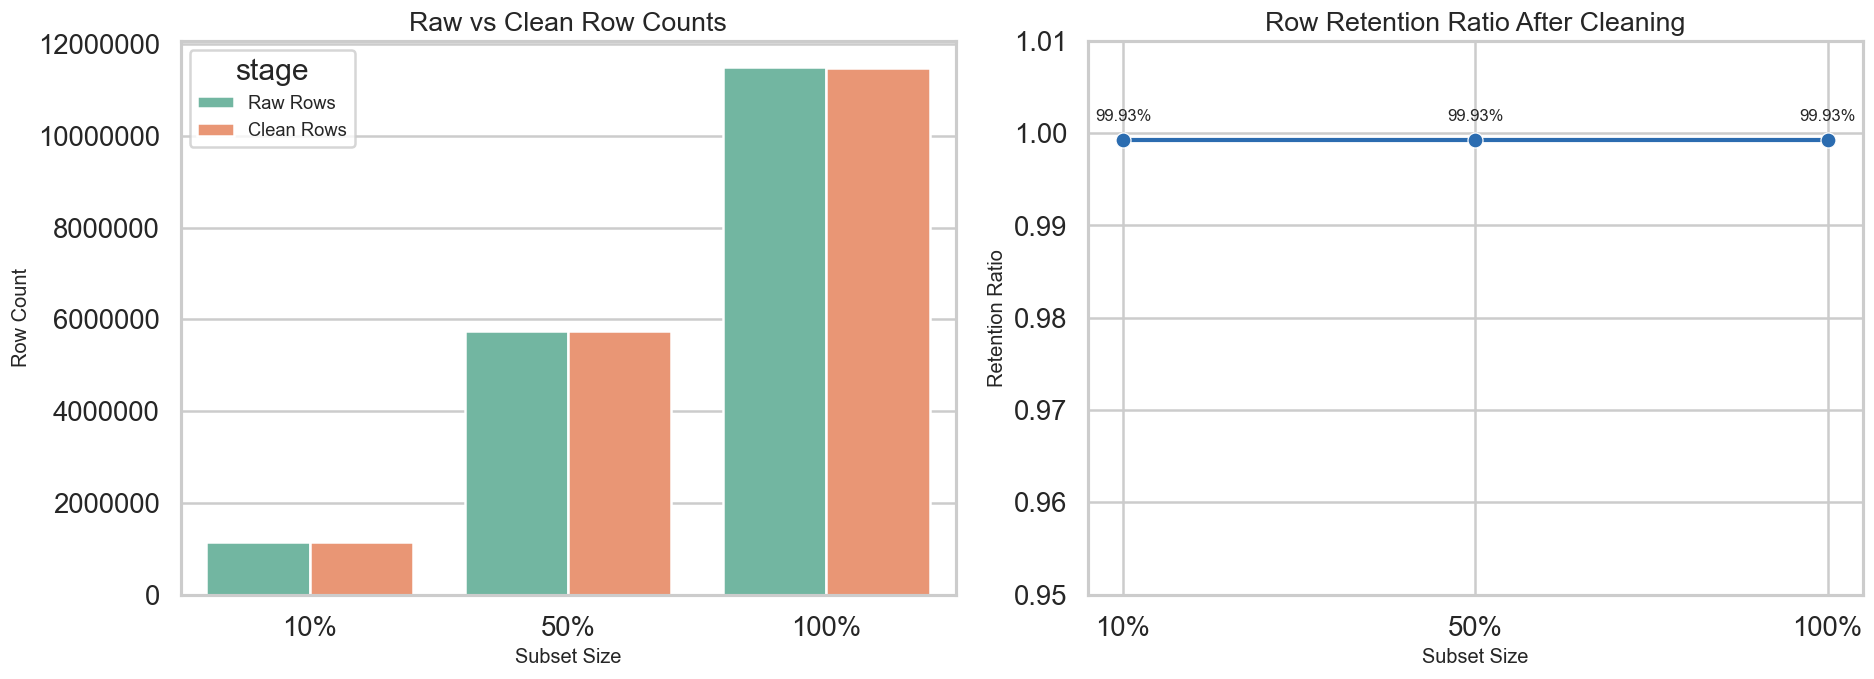

图表已保存: /Users/fangflak/Desktop/CI_proj/artifacts/figures/preprocessing_benchmark_comparison.png


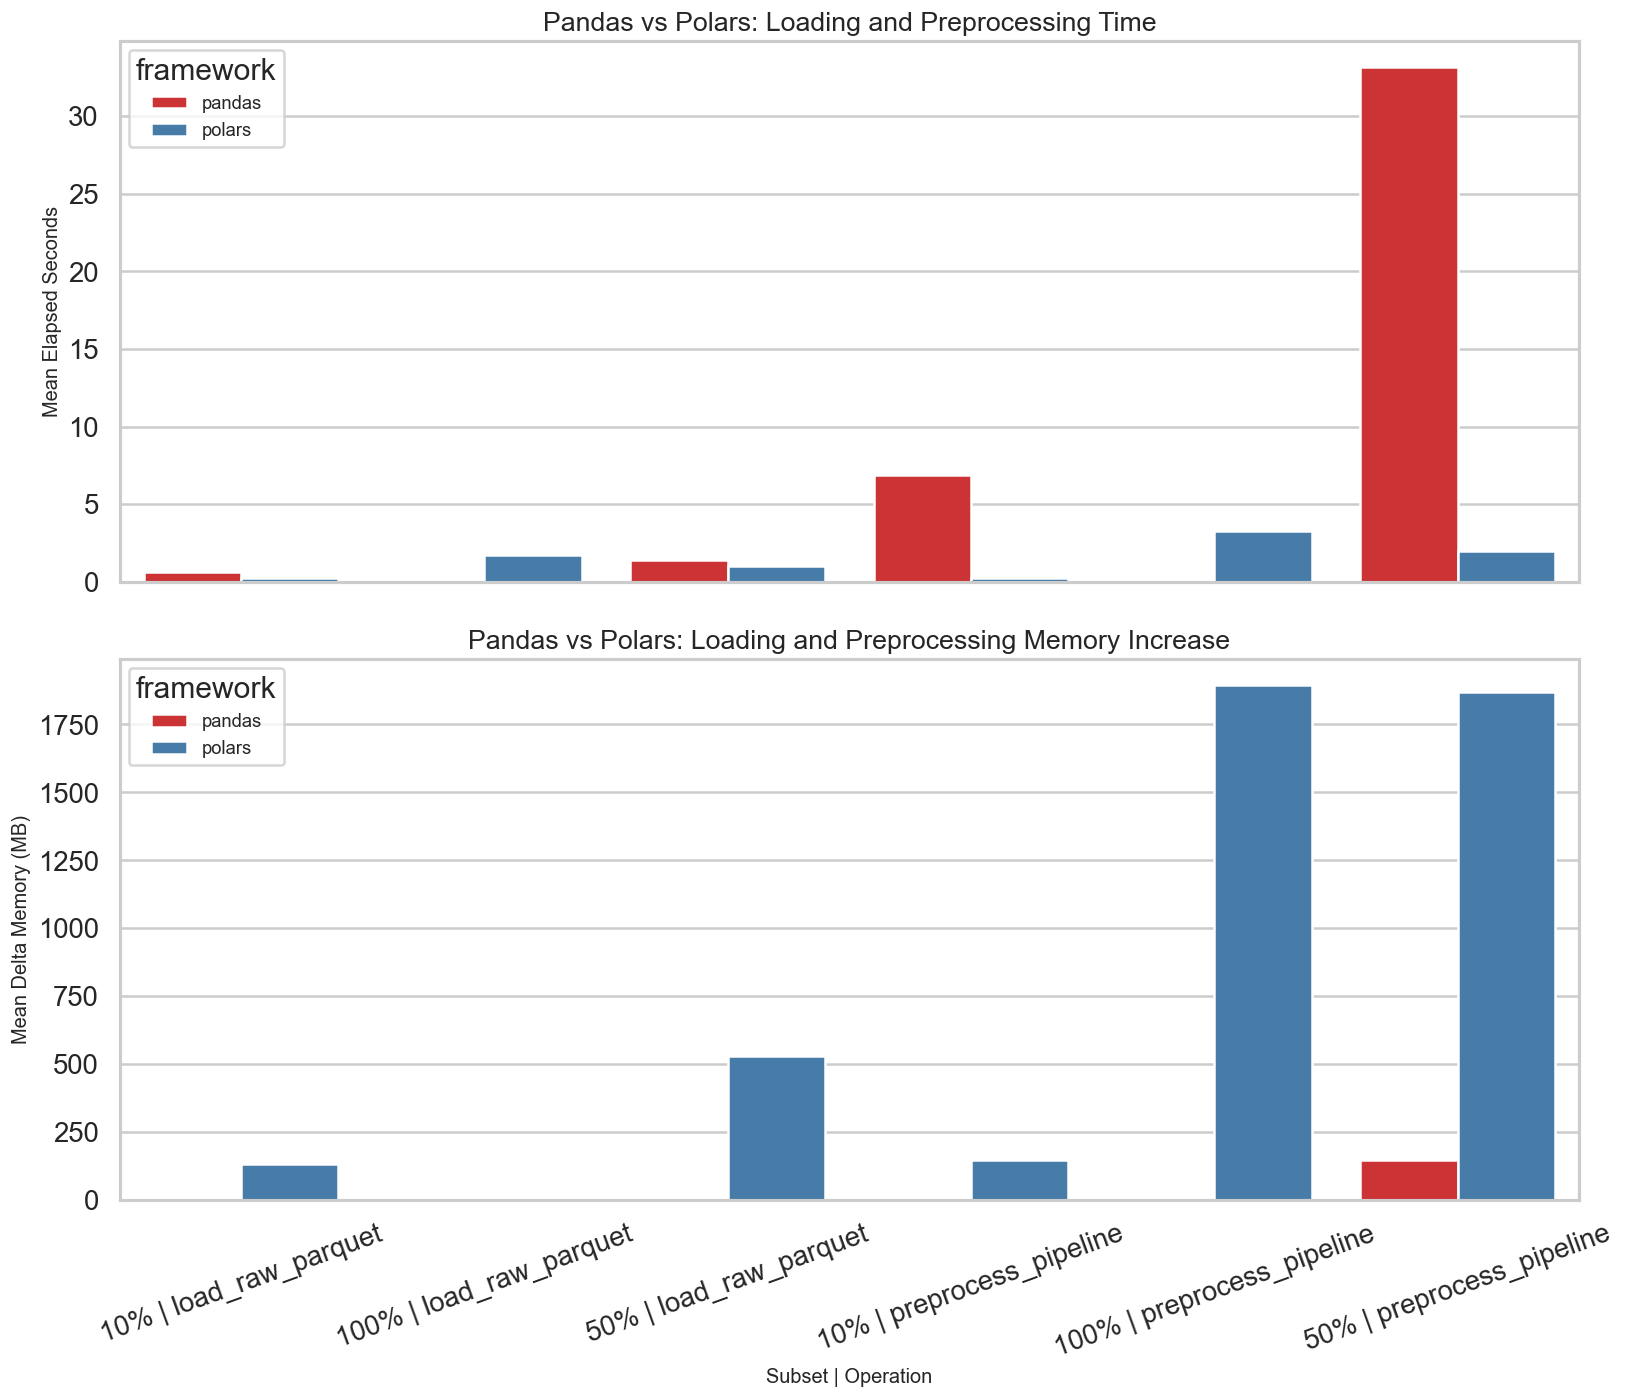

,subset_label,fraction,raw_subset_path,raw_row_count,clean_subset_path,clean_row_count,dropped_rows_in_cleaning,drop_ratio,retention_ratio
0,10%,0.1,/Users/fangflak/Desktop/CI_proj/artifacts/raw_...,1149524,/Users/fangflak/Desktop/CI_proj/artifacts/clea...,1148774,750,0.0007,0.9993
1,50%,0.5,/Users/fangflak/Desktop/CI_proj/artifacts/raw_...,5747621,/Users/fangflak/Desktop/CI_proj/artifacts/clea...,5743817,3804,0.0007,0.9993
2,100%,1.0,/Users/fangflak/Desktop/CI_proj/train.parquet,11495242,/Users/fangflak/Desktop/CI_proj/artifacts/clea...,11487615,7627,0.0007,0.9993


In [9]:

cleaning_report_df = raw_subset_registry.merge(clean_subset_registry, on="subset_label", how="left")
cleaning_report_df["retention_ratio"] = (
    cleaning_report_df["clean_row_count"] / cleaning_report_df["raw_row_count"]
).round(4)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_df = cleaning_report_df.melt(
    id_vars="subset_label",
    value_vars=["raw_row_count", "clean_row_count"],
    var_name="stage",
    value_name="row_count",
)
plot_df["stage"] = plot_df["stage"].map(
    {
        "raw_row_count": "Raw Rows",
        "clean_row_count": "Clean Rows",
    }
)

sns.barplot(data=plot_df, x="subset_label", y="row_count", hue="stage", palette="Set2", ax=axes[0])
axes[0].set_title("Raw vs Clean Row Counts")
axes[0].set_xlabel("Subset Size")
axes[0].set_ylabel("Row Count")
axes[0].ticklabel_format(style="plain", axis="y")

sns.lineplot(
    data=cleaning_report_df,
    x="subset_label",
    y="retention_ratio",
    marker="o",
    linewidth=2.5,
    color="#2b6cb0",
    ax=axes[1],
)
axes[1].set_title("Row Retention Ratio After Cleaning")
axes[1].set_xlabel("Subset Size")
axes[1].set_ylabel("Retention Ratio")
axes[1].set_ylim(0.95, 1.01)
for idx, value in enumerate(cleaning_report_df["retention_ratio"]):
    axes[1].text(idx, value + 0.002, f"{value:.2%}", ha="center", fontsize=10)

save_current_figure("cleaning_scale_comparison.png")
plt.show()

preprocess_plot_df = benchmark_preprocess_summary.loc[
    benchmark_preprocess_summary["status"] == "completed"
].copy()
preprocess_plot_df["subset_operation"] = (
    preprocess_plot_df["subset_label"] + " | " + preprocess_plot_df["operation"]
)

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

sns.barplot(
    data=preprocess_plot_df,
    x="subset_operation",
    y="mean_elapsed_seconds",
    hue="framework",
    palette="Set1",
    ax=axes[0],
)
axes[0].set_title("Pandas vs Polars: Loading and Preprocessing Time")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean Elapsed Seconds")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=preprocess_plot_df,
    x="subset_operation",
    y="mean_delta_memory_mb",
    hue="framework",
    palette="Set1",
    ax=axes[1],
)
axes[1].set_title("Pandas vs Polars: Loading and Preprocessing Memory Increase")
axes[1].set_xlabel("Subset | Operation")
axes[1].set_ylabel("Mean Delta Memory (MB)")
axes[1].tick_params(axis="x", rotation=20)

save_current_figure("preprocessing_benchmark_comparison.png")
plt.show()

display(cleaning_report_df)



### Cell 10: 输出代表性聚合任务对比图与速度提升图

这一部分强调 report 中最容易说明性能差异的两类图：

- 日级事件统计与会话长度统计的执行时间、内存对比
- 以 `Pandas / Polars` 速度比表示的加速倍数图


图表已保存: /Users/fangflak/Desktop/CI_proj/artifacts/figures/aggregation_benchmark_comparison.png


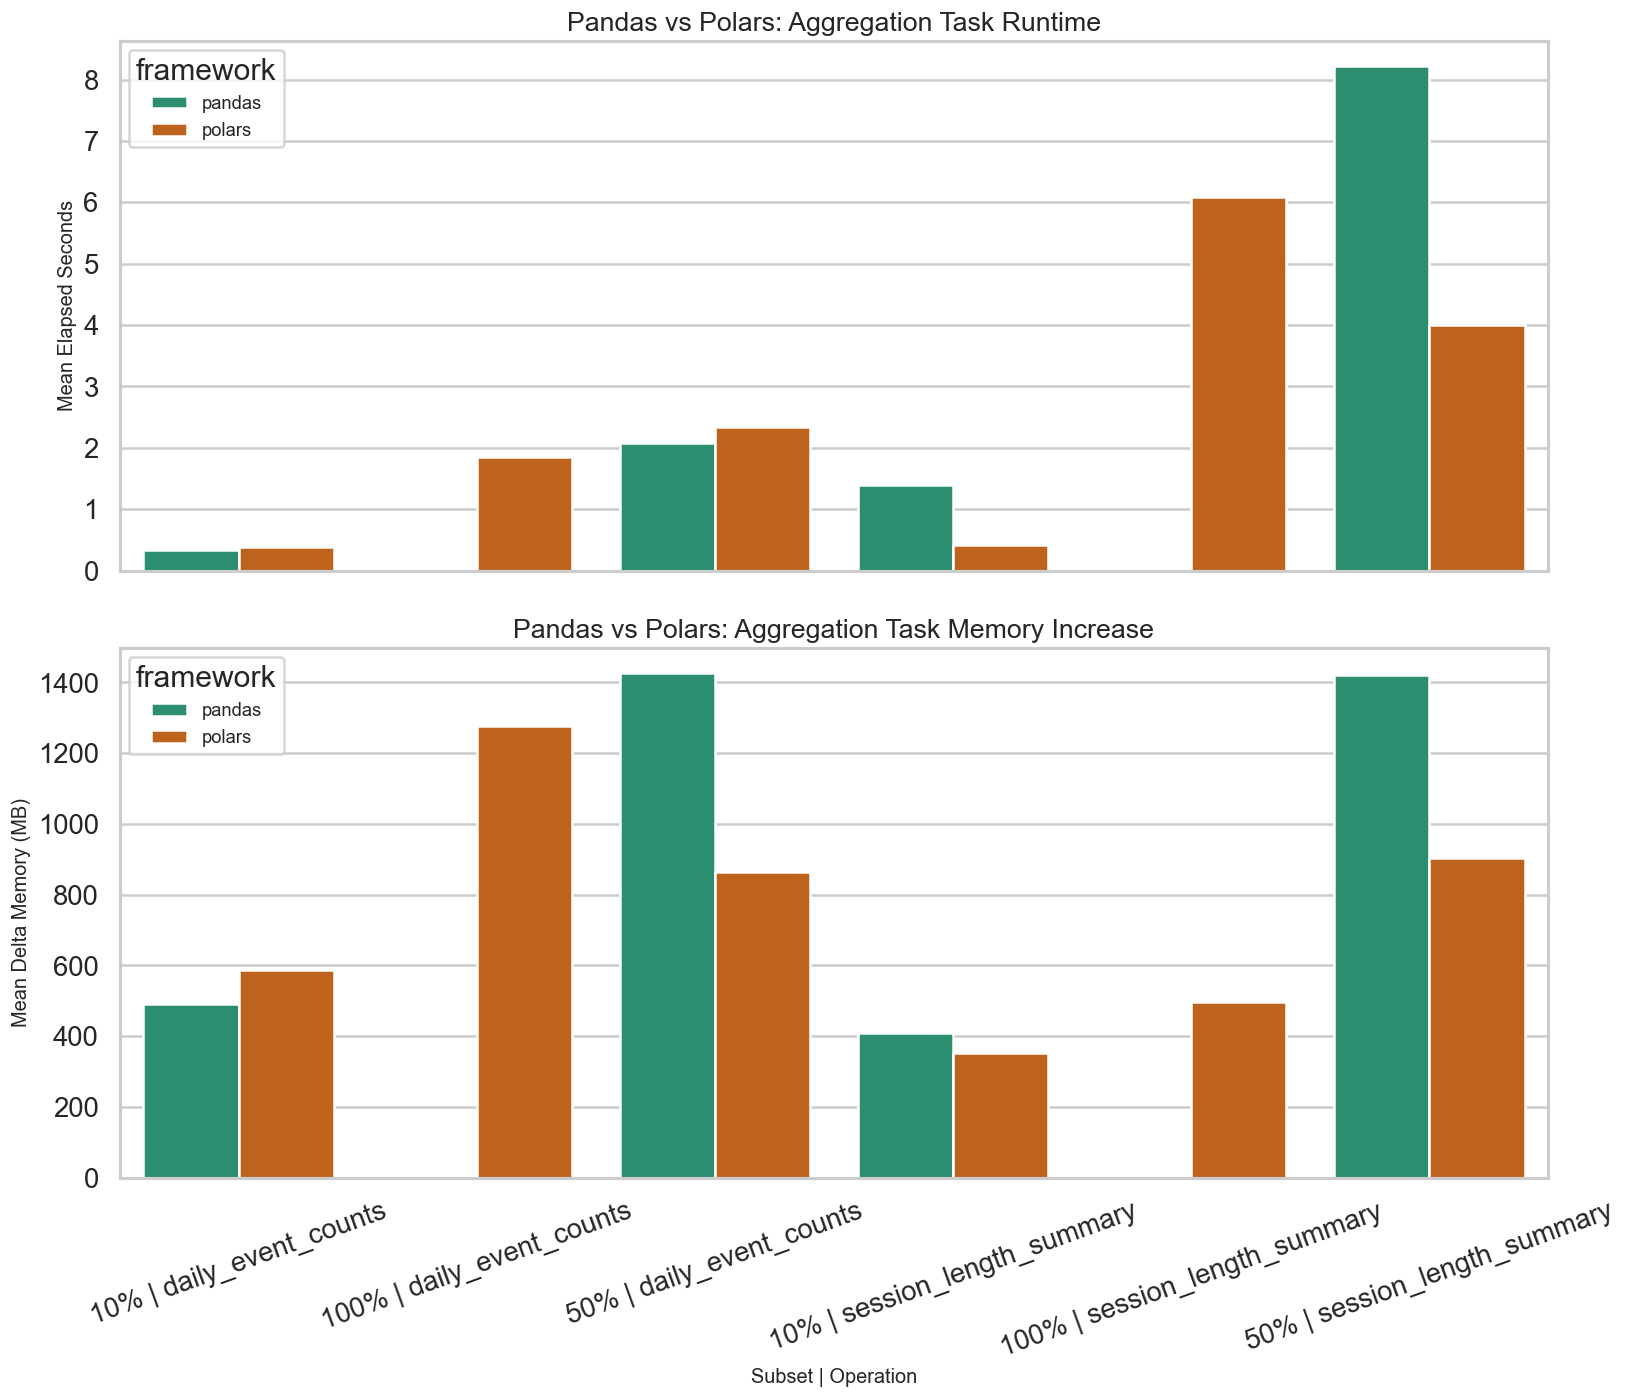

图表已保存: /Users/fangflak/Desktop/CI_proj/artifacts/figures/runtime_speedup_ratio.png


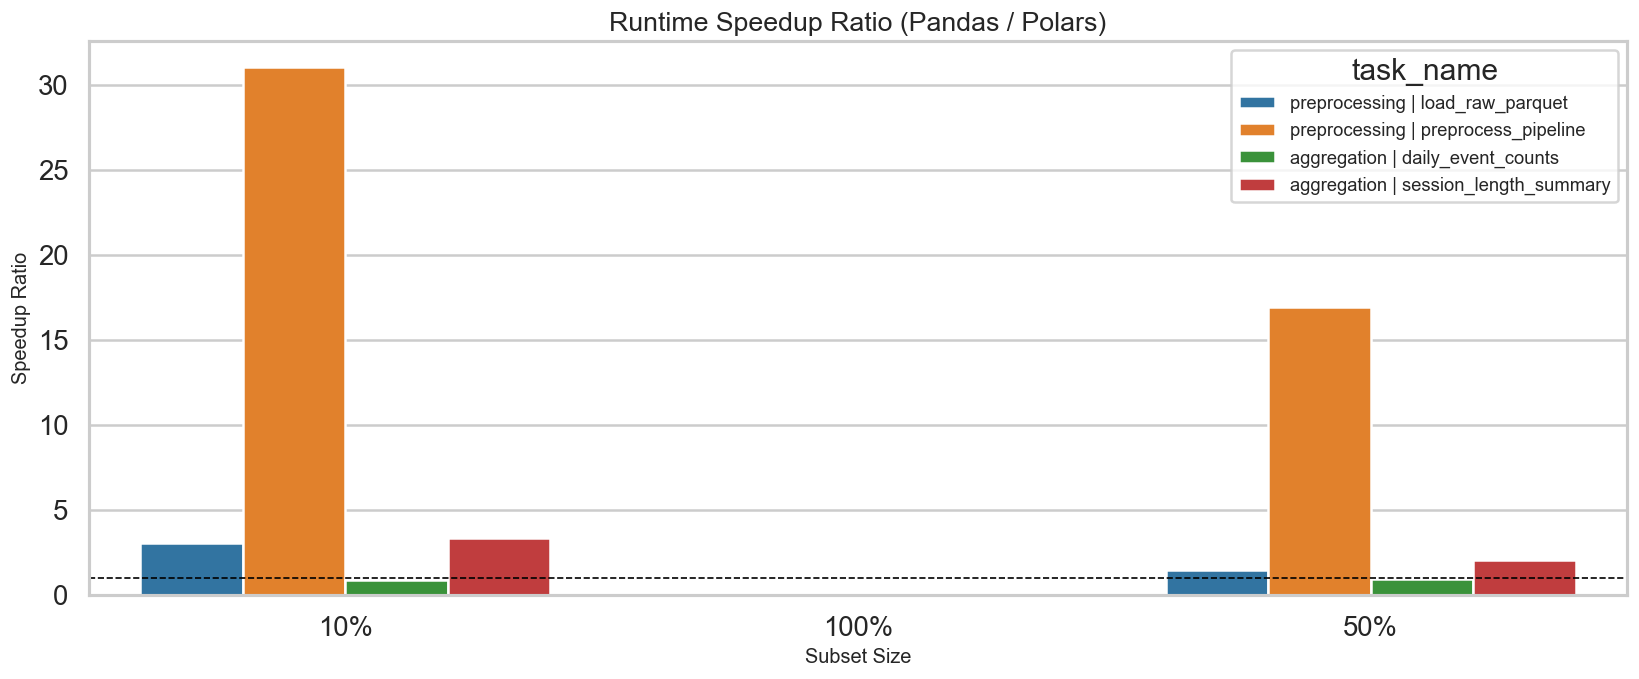

可直接放入 report 的图表文件：
/Users/fangflak/Desktop/CI_proj/artifacts/figures/aggregation_benchmark_comparison.png
/Users/fangflak/Desktop/CI_proj/artifacts/figures/cleaning_scale_comparison.png
/Users/fangflak/Desktop/CI_proj/artifacts/figures/preprocessing_benchmark_comparison.png
/Users/fangflak/Desktop/CI_proj/artifacts/figures/runtime_speedup_ratio.png


In [10]:

aggregation_plot_df = aggregation_benchmark_summary.loc[
    aggregation_benchmark_summary["status"] == "completed"
].copy()
aggregation_plot_df["subset_operation"] = (
    aggregation_plot_df["subset_label"] + " | " + aggregation_plot_df["operation"]
)

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

sns.barplot(
    data=aggregation_plot_df,
    x="subset_operation",
    y="mean_elapsed_seconds",
    hue="framework",
    palette="Dark2",
    ax=axes[0],
)
axes[0].set_title("Pandas vs Polars: Aggregation Task Runtime")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean Elapsed Seconds")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=aggregation_plot_df,
    x="subset_operation",
    y="mean_delta_memory_mb",
    hue="framework",
    palette="Dark2",
    ax=axes[1],
)
axes[1].set_title("Pandas vs Polars: Aggregation Task Memory Increase")
axes[1].set_xlabel("Subset | Operation")
axes[1].set_ylabel("Mean Delta Memory (MB)")
axes[1].tick_params(axis="x", rotation=20)

save_current_figure("aggregation_benchmark_comparison.png")
plt.show()

speedup_frames = []
for speedup_df, benchmark_group in [
    (benchmark_preprocess_speedup, "preprocessing"),
    (aggregation_speedup, "aggregation"),
]:
    if not speedup_df.empty and "time_speedup_pandas_div_polars" in speedup_df.columns:
        temp_df = speedup_df[["subset_label", "operation", "time_speedup_pandas_div_polars"]].copy()
        temp_df["benchmark_group"] = benchmark_group
        speedup_frames.append(temp_df)

speedup_report_df = pd.concat(speedup_frames, ignore_index=True)
speedup_report_df["task_name"] = speedup_report_df["benchmark_group"] + " | " + speedup_report_df["operation"]

plt.figure(figsize=(14, 6))
sns.barplot(
    data=speedup_report_df,
    x="subset_label",
    y="time_speedup_pandas_div_polars",
    hue="task_name",
    palette="tab10",
)
plt.axhline(1.0, color="black", linestyle="--", linewidth=1)
plt.title("Runtime Speedup Ratio (Pandas / Polars)")
plt.xlabel("Subset Size")
plt.ylabel("Speedup Ratio")

save_current_figure("runtime_speedup_ratio.png")
plt.show()

print("可直接放入 report 的图表文件：")
for figure_path in sorted(FIGURE_DIR.glob("*.png")):
    print(figure_path)



### Cell 11: 小结与后续衔接说明

到这里，Notebook 已完成两个目标：

- 数据预处理：统一处理 `"NA"` 缺失标记、价格异常、标准化时间列，并输出可复用的清洗子集。
- 性能评估基准：形成 Pandas 与 Polars 在数据加载、预处理、时间聚合、会话聚合四类任务上的对比结果。

后续如果继续完成 EDA、用户行为分析或推荐导向分析，可以直接复用以下目录中的输出：

- `artifacts/raw_subsets/`
- `artifacts/clean_subsets/`

建议优先基于 `clean_subsets` 中的数据继续建模与可视化，这样可以避免在后续模块里重复执行清洗逻辑。
